# avGFP DMS — log-brightness architecture sweep results

Visualizes the single prediction-model sweep in `sweep_brightness.py`, which regresses the
Sarkisyan et al. (2016) avGFP **log10 median brightness** from ESM-2 650M per-residue embeddings.

Same backbone × pooling × depth grid as `esm2_design/sweep_results.ipynb` (35 configs), but one
model only — no surrogate/oracle split. Metrics are in **log10-brightness** units (MAE, RMSE,
Pearson r, R²) on the 70/15/15 val/test split.

Run the sweep first: `python sweep_brightness.py` (needs `DMS_data/esm_residue_fp16.npy`).

In [1]:
# Shared loaders + plotters for the avGFP DMS log-brightness sweep.
# Self-contained analogue of esm2_design/sweep_results.ipynb (single model, no roles).
import glob, os, sys
import numpy as np, pandas as pd, torch
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FS = 12
plt.rcParams.update({"font.size": FS, "axes.titlesize": FS, "axes.labelsize": FS,
                     "xtick.labelsize": FS, "ytick.labelsize": FS, "legend.fontsize": FS})

SWEEP_DIR = "trained_models/sweep"
UNIT = "log10-brightness"
BB = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
POOL_C = {"mean": "#9a9a9a", "max": "#2b6c8f", "concat": "#f6a200", "concatstd": "#c5474b",
          "attn": "#3b8a6e", "cov": "#8156a7"}
ARCH_M = {"mlp": "o", "cnn": "s", "transformer": "^"}
POOL_ORDER = ["mean", "max", "concat", "concatstd", "attn", "cov"]


def load_sweep(out_dir=SWEEP_DIR):
    """Read every checkpoint in the sweep dir into a leaderboard DataFrame (ranked by val MAE)."""
    recs = []
    for p in sorted(glob.glob(f"{out_dir}/*.pt")):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        recs.append(dict(arch=ck["arch"], pool=ck["pool"], depth=ck.get("depth"), seed=ck.get("seed", 0),
                         val_mae=ck["val_mae"], val_rmse=ck.get("val_rmse"), val_pearson=ck.get("val_pearson"),
                         val_r2=ck.get("val_r2"), test_mae=ck["test_mae"], test_rmse=ck.get("test_rmse"),
                         test_pearson=ck.get("test_pearson"), test_r2=ck.get("test_r2"),
                         label=f"{BB[ck['arch']]} ({ck.get('depth')}) - {ck['pool']}",
                         file=os.path.basename(p)))
    if not recs:
        print(f"No checkpoints in {out_dir}/. Run:  python sweep_brightness.py")
        return pd.DataFrame()
    return pd.DataFrame(recs).sort_values("val_mae").reset_index(drop=True)


def show_table(df, n=40):
    if df.empty:
        return df
    cols = ["label", "arch", "pool", "depth", "val_mae", "val_rmse", "val_pearson", "val_r2",
            "test_mae", "test_pearson", "test_r2"]
    num = [c for c in cols if df[c].dtype != object]
    return (df[cols].head(n).style.format({c: "{:.3f}" for c in num})
            .background_gradient(subset=["val_mae"], cmap="viridis_r"))


def plot_bar(df, title, metric="val_mae", nulls=None):
    if df.empty:
        return
    d = df.sort_values(metric).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(range(len(d)), d[metric], color=[POOL_C.get(p, "#333") for p in d["pool"]],
           edgecolor="k", linewidth=0.4)
    ax.set_xticks(range(len(d))); ax.set_xticklabels(d["label"], rotation=90, fontsize=7)
    ax.set_ylabel(f"{metric} ({UNIT})"); ax.set_title(title)
    if nulls:
        for name, v in nulls.items():
            ax.axhline(v, ls="--", lw=1, color="k")
            ax.text(len(d) - 0.5, v, f" {name}={v:.3f}", va="bottom", ha="right", fontsize=8)
    ax.legend(handles=[Patch(facecolor=POOL_C[p], label=p) for p in POOL_ORDER],
              title="pool", ncol=5, fontsize=8)
    plt.tight_layout(); plt.show()


def plot_scatter(df):
    """val vs test MAE (generalization check): marker=backbone, color=pool."""
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(5, 5))
    for arch, mk in ARCH_M.items():
        s = df[df["arch"] == arch]
        if len(s):
            ax.scatter(s["val_mae"], s["test_mae"], c=[POOL_C.get(p) for p in s["pool"]],
                       marker=mk, edgecolor="k", linewidth=0.4, s=60, label=arch)
    lo = float(min(df["val_mae"].min(), df["test_mae"].min()))
    hi = float(max(df["val_mae"].max(), df["test_mae"].max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel(f"val MAE ({UNIT})"); ax.set_ylabel(f"test MAE ({UNIT})")
    ax.set_title("val vs test MAE"); ax.legend(title="backbone")
    plt.tight_layout(); plt.show()

In [2]:
# Prediction machinery + null baselines. Reuses sweep_brightness to load the (memmapped)
# embeddings and the persisted split, runs the best checkpoint on val/test, and compares to
# simple nulls. peak_models is resolved via sweep_brightness's own path insert (../esm2_design).
sys.path.insert(0, os.path.abspath("."))          # this notebook's dir (avGFP_DMS/)
import sweep_brightness as sw
import peak_models as pm
dev = sw.device(); print("device:", dev)

_D = {}
def get_data():
    # These plots only ever predict on val/test (and the train-mean null needs just y[tr]), so
    # stream from the memmap: cache_ram=False avoids materializing the 21.8 GB train split in RAM.
    if "D" not in _D:
        _D["D"] = sw.load_data(dev, cache_ram=False)
    return _D["D"]

def load_net(ckpt_file, sweep_dir=SWEEP_DIR):
    base, ck = pm.load_model(os.path.join(sweep_dir, ckpt_file), dev, out=1)
    net = pm.wrap(base, ck["mean"], ck["std"], dev); net.eval()
    return net

# Disk-cached predictions: streaming val/test from the 31 GB memmap costs ~45 s/split, so persist
# (P, T) per checkpoint+split. Later runs (incl. after a kernel restart) load in ms and never open
# the memmap. Cache is keyed by dir+checkpoint+split; delete PRED_CACHE/ or pass refresh=True to redo.
PRED_CACHE = "trained_models/pred_cache"
_PRED = {}
def get_pred(ckpt_file, split, sweep_dir=SWEEP_DIR, refresh=False):
    """Return (P, T): continuous predictions and true targets for a split, cached in RAM and on disk."""
    key = (sweep_dir, ckpt_file, split)
    if key not in _PRED:
        os.makedirs(PRED_CACHE, exist_ok=True)
        tag = f"{os.path.basename(os.path.normpath(sweep_dir))}__{ckpt_file[:-3]}__{split}.npz"
        fp = os.path.join(PRED_CACHE, tag)
        if os.path.exists(fp) and not refresh:
            z = np.load(fp); _PRED[key] = (z["P"], z["T"])
        else:
            D = get_data(); idx = D["va"] if split == "va" else D["te"]
            P, idx = sw.predict(load_net(ckpt_file, sweep_dir), D, idx, dev)  # idx sorted -> align truth
            T = D["y"][idx]
            np.savez(fp, P=P, T=T, idx=idx); _PRED[key] = (P, T)
    return _PRED[key]

def pred_vs_truth(df, split="va", sweep_dir=SWEEP_DIR):
    """Hexbin of predicted vs true log-brightness for the top-ranked config on val or test."""
    if df.empty:
        return
    row = df.iloc[0]
    P, T = get_pred(row["file"], split, sweep_dir)
    mae, rmse, r, r2 = sw.metrics(P, T)
    fig, ax = plt.subplots(figsize=(5.4, 5))
    hb = ax.hexbin(T, P, gridsize=60, bins="log", cmap="viridis", mincnt=1)
    lo, hi = float(min(T.min(), P.min())), float(max(T.max(), P.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel(f"true {UNIT}"); ax.set_ylabel(f"predicted {UNIT}")
    ax.set_title(f"{row['label']}  [{'val' if split == 'va' else 'test'}]\n"
                 f"MAE {mae:.3f}  RMSE {rmse:.3f}  r {r:.3f}  R\u00b2 {r2:.3f}")
    fig.colorbar(hb, ax=ax, label="log10 count"); plt.tight_layout(); plt.show()
    return dict(mae=mae, rmse=rmse, pearson=r, r2=r2)

def null_baselines():
    """Val-MAE nulls (log-brightness): predict the train mean, and kNN on mean-pooled embeddings.
    NOTE: the kNN null streams the full 31 GB embedding memmap once (~1 min)."""
    D = get_data(); out = {"train-mean": float(np.abs(D["y"][D["va"]] - D["y"][D["tr"]].mean()).mean())}
    try:
        from sklearn.neighbors import KNeighborsRegressor
        H, Ls = D["H"], D["Ls"]; N, L, C = H.shape
        mp = np.zeros((N, C), np.float32)
        for i in range(0, N, 512):
            j1 = min(i + 512, N); block = np.asarray(H[i:j1]).astype(np.float32)
            for k in range(block.shape[0]):
                n = int(Ls[i + k]); mp[i + k] = block[k, :n].mean(0) if n else 0.0
        knn = KNeighborsRegressor(n_neighbors=5).fit(mp[D["tr"]], D["y"][D["tr"]])
        out["kNN-5 (mean-pool)"] = float(np.abs(knn.predict(mp[D["va"]]) - D["y"][D["va"]]).mean())
    except Exception as e:
        print("kNN baseline skipped:", e)
    return out

device: cuda


## Leaderboard

All 35 configs ranked by validation MAE (log10-brightness). Lower MAE / higher Pearson r & R² is better.

In [3]:
df = load_sweep()
show_table(df)

,label,arch,pool,depth,val_mae,val_rmse,val_pearson,val_r2,test_mae,test_pearson,test_r2
0,CNN (1) - max,cnn,max,1.000,0.267,0.455,0.905,0.816,0.253,0.919,0.841
1,CNN (1) - concat,cnn,concat,1.000,0.306,0.508,0.878,0.770,0.323,0.862,0.743
2,CNN (2) - concat,cnn,concat,2.000,0.308,0.555,0.858,0.726,0.309,0.862,0.731
3,CNN (3) - concat,cnn,concat,3.000,0.326,0.558,0.857,0.723,0.326,0.857,0.722
4,CNN (3) - max,cnn,max,3.000,0.336,0.597,0.833,0.682,0.328,0.845,0.702
5,TF (1) - max,transformer,max,1.000,0.339,0.556,0.851,0.725,0.329,0.860,0.739
6,CNN (2) - max,cnn,max,2.000,0.341,0.573,0.844,0.707,0.329,0.855,0.727
7,CNN (3) - mean,cnn,mean,3.000,0.349,0.573,0.841,0.707,0.346,0.848,0.720
8,CNN (3) - attn,cnn,attn,3.000,0.352,0.599,0.829,0.680,0.356,0.831,0.683
9,CNN (1) - concatstd,cnn,concatstd,1.000,0.352,0.611,0.833,0.667,0.342,0.845,0.690


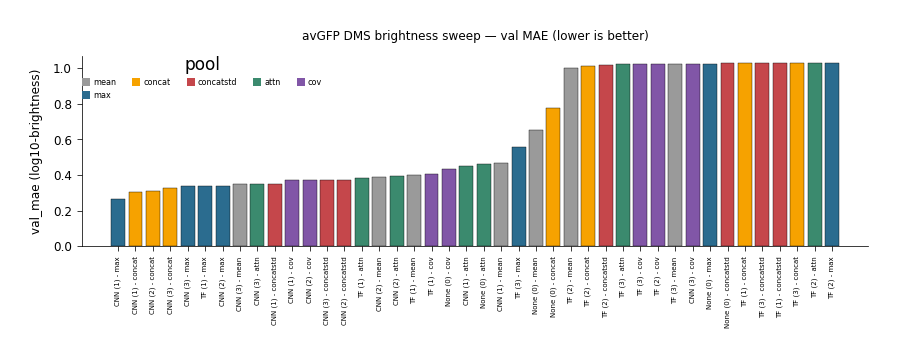

In [4]:
plot_bar(df, "avGFP DMS brightness sweep — val MAE (lower is better)")

## Generalization: validation vs test MAE

Points on the diagonal generalize; points well above it overfit the validation split.

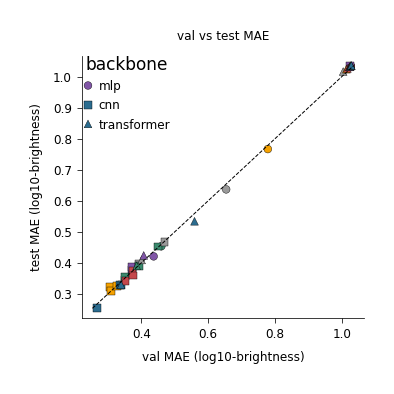

In [5]:
plot_scatter(df)

## Predicted vs. true log-brightness (best model)

Hexbin density of the top-ranked config on the validation and test splits. The dashed red line is
the ideal `y = x`; the bimodal structure (dark ~1.3 floor vs. bright ~3.6 peak) should be visible.

streaming all splits from the on-disk memmap (31.1 GB)


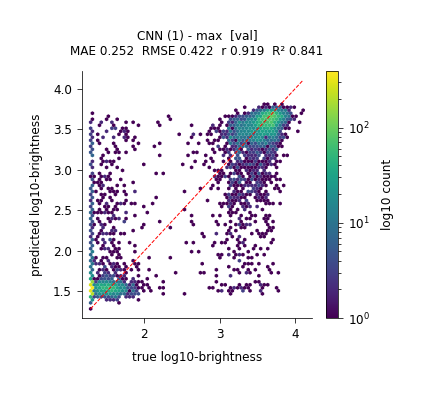

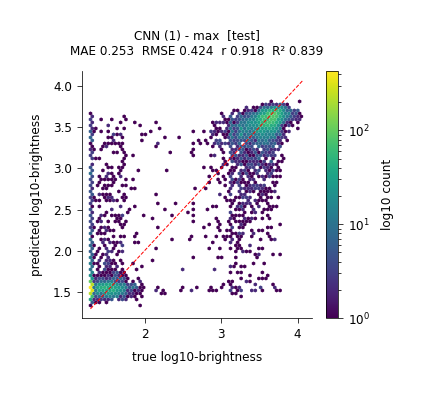

{'mae': 0.2526339203853098,
 'rmse': 0.42381330523477323,
 'pearson': 0.9175446656257935,
 'r2': 0.8391145024499393}

In [6]:
pred_vs_truth(df, split="va")
pred_vs_truth(df, split="te")

## Null baselines (optional)

Reference floors for the val MAE: predicting the constant train mean, and a k-NN regressor on
mean-pooled embeddings. A useful model should beat both. The k-NN null streams the full 31 GB
embedding cache once (~1 min).

val-MAE nulls: {'train-mean': 1.028, 'kNN-5 (mean-pool)': 0.676}


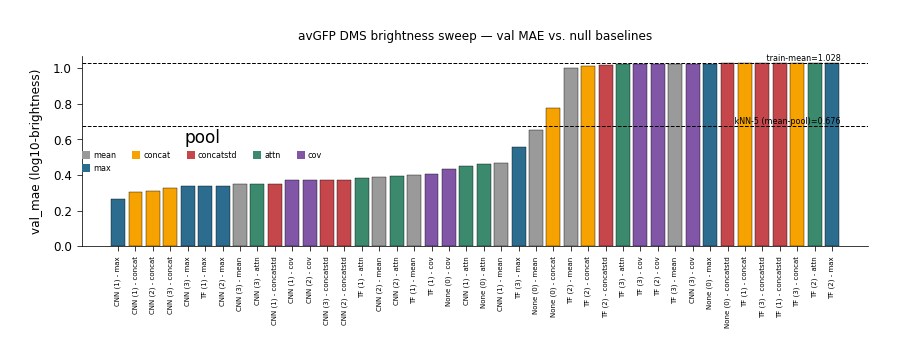

In [7]:
nulls = null_baselines()
print("val-MAE nulls:", {k: round(v, 3) for k, v in nulls.items()})
plot_bar(df, "avGFP DMS brightness sweep — val MAE vs. null baselines", nulls=nulls)

## Regressor as a classifier (post-hoc threshold, no retraining)

The log-brightness target is strongly **bimodal** — a non-functional (*dark*) pile at the floor and a
functional (*bright*) mode near WT, separated by a nearly empty valley (~2.0–2.9). So the trained
**regressor doubles as a classifier**: label variants *bright* if the *true* brightness ≥ `LABEL_THRESH`
(a cutoff in the valley), score them by the model's *continuous* prediction, and pick the decision
threshold on val. AUROC/AUPRC are threshold-free; accuracy/F1/confusion use the val-optimized cutoff.

Uses the full-data models in `trained_models/full/` (whose seed-0 split matches this notebook's split).

model: CNN (1) - max   label thresh (true)=2.5   decision thresh (val-opt)=2.962
val : AUROC 0.993  AUPRC 0.994   (bright=57.8%)
test: AUROC 0.993  AUPRC 0.995   acc 0.968  F1 0.972  prec 0.967  rec 0.978
test confusion  [[TN 3059  FP 151] [FN 101  TP 4446]]


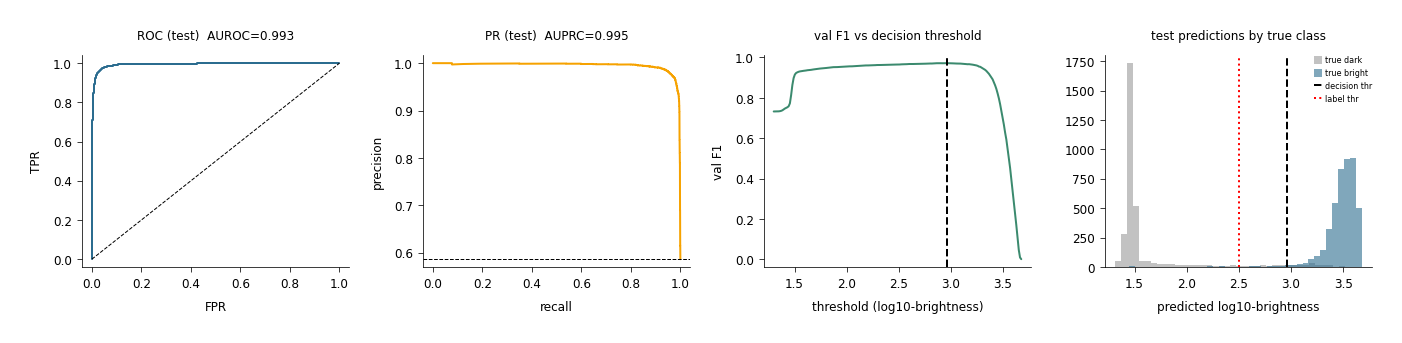

In [8]:
# Post-hoc classifier from the trained regressor: threshold its continuous prediction.
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, f1_score, confusion_matrix)

FULL_DIR = "trained_models/full"
LABEL_THRESH = 2.5          # true log-brightness cutoff (sits in the empty valley): dark vs bright

def classifier_report(df, sweep_dir=FULL_DIR, label_thresh=LABEL_THRESH):
    """Treat the top-ranked regressor as a bright/dark classifier: rank metrics (AUROC/AUPRC) plus
    accuracy/F1/confusion at the val-optimized decision threshold. Reports val + test.
    Predictions come from the disk-cached get_pred, so this is instant after the first run."""
    if df.empty:
        print("no checkpoints"); return
    row = df.iloc[0]
    Pv, Tv = get_pred(row["file"], "va", sweep_dir); yv = (Tv >= label_thresh).astype(int)
    Pt, Tt = get_pred(row["file"], "te", sweep_dir); yt = (Tt >= label_thresh).astype(int)

    auroc_v, auroc_t = roc_auc_score(yv, Pv), roc_auc_score(yt, Pt)      # score = predicted brightness
    auprc_v, auprc_t = average_precision_score(yv, Pv), average_precision_score(yt, Pt)

    grid = np.linspace(Pv.min(), Pv.max(), 200)                          # pick decision thr on VAL (max F1)
    f1s = np.array([f1_score(yv, (Pv >= t).astype(int), zero_division=0) for t in grid])
    thr = float(grid[int(f1s.argmax())])
    yhat = (Pt >= thr).astype(int); cm = confusion_matrix(yt, yhat); tn, fp, fn, tp = cm.ravel()
    acc = float((yhat == yt).mean()); f1t = f1_score(yt, yhat)
    prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0

    print(f"model: {row['label']}   label thresh (true)={label_thresh}   decision thresh (val-opt)={thr:.3f}")
    print(f"val : AUROC {auroc_v:.3f}  AUPRC {auprc_v:.3f}   (bright={yv.mean()*100:.1f}%)")
    print(f"test: AUROC {auroc_t:.3f}  AUPRC {auprc_t:.3f}   acc {acc:.3f}  F1 {f1t:.3f}  "
          f"prec {prec:.3f}  rec {rec:.3f}")
    print(f"test confusion  [[TN {tn}  FP {fp}] [FN {fn}  TP {tp}]]")

    fig, ax = plt.subplots(1, 4, figsize=(19, 4.3))
    fpr, tpr, _ = roc_curve(yt, Pt); ax[0].plot(fpr, tpr, color=POOL_C["max"]); ax[0].plot([0, 1], [0, 1], "k--", lw=1)
    ax[0].set_title(f"ROC (test)  AUROC={auroc_t:.3f}"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
    pr, rc, _ = precision_recall_curve(yt, Pt); ax[1].plot(rc, pr, color=POOL_C["concat"])
    ax[1].axhline(yt.mean(), ls="--", lw=1, color="k"); ax[1].set_title(f"PR (test)  AUPRC={auprc_t:.3f}")
    ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
    ax[2].plot(grid, f1s, color=POOL_C["attn"]); ax[2].axvline(thr, ls="--", color="k")
    ax[2].set_title("val F1 vs decision threshold"); ax[2].set_xlabel(f"threshold ({UNIT})"); ax[2].set_ylabel("val F1")
    ax[3].hist(Pt[yt == 0], bins=40, alpha=0.6, label="true dark", color="#9a9a9a")
    ax[3].hist(Pt[yt == 1], bins=40, alpha=0.6, label="true bright", color=POOL_C["max"])
    ax[3].axvline(thr, ls="--", color="k", label="decision thr"); ax[3].axvline(label_thresh, ls=":", color="r", label="label thr")
    ax[3].set_title("test predictions by true class"); ax[3].set_xlabel(f"predicted {UNIT}"); ax[3].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return dict(threshold=thr, auroc_test=auroc_t, auprc_test=auprc_t, acc_test=acc, f1_test=f1t)

df_full = load_sweep(FULL_DIR)
_ = classifier_report(df_full)

## Predicted brightness vs. mutation load

How fast does the model's predicted brightness decay as a sequence moves away from the avGFP parent?
We draw random multi-point mutants — `k ∈ {1, 2, 5, 10, 20}` substitutions at random positions, each to a
random *different* amino acid — **1,000 per level (5,000 variants total)** — and score them with the best
full-data model, **CNN(1)-max** (`trained_models/full/cnn-max-d1_s0.pt`).

This contextualizes why heavily-mutated designs collapse to the dark floor: e.g. the EGFP-pocket redesigns
carry 13–25 simultaneous mutations, a load at which essentially no variant is predicted bright.

In [9]:
# Generate random k-mutant variants of the avGFP parent and score them with CNN(1)-max.
from collections import Counter

MUT_LEVELS   = [1, 2, 5, 10, 20]     # substitutions per variant
N_PER_LEVEL  = 1000                  # 5 x 1000 = 5,000 variants total
BEST_FULL    = "cnn-max-d1_s0.pt"    # top full-data model (CNN, depth 1, max-pool)
AAS          = "ACDEFGHIKLMNPQRSTVWY"
mut_rng      = np.random.default_rng(0)

# avGFP DMS parent (235 aa) reconstructed as the per-position consensus of the dataset.
_dms   = pd.read_csv("DMS_data/avgfp_dms_sequences.csv")
_arr   = np.array([list(s) for s in _dms.mutatedSequence.values])
PARENT = "".join(Counter(_arr[:, j]).most_common(1)[0][0] for j in range(_arr.shape[1]))
Lp     = len(PARENT)
print(f"avGFP parent: {Lp} aa | {PARENT[:24]}...")

def make_variant(k):
    """Parent with k random substitutions (distinct positions, each to a different amino acid)."""
    seq = list(PARENT)
    for p in mut_rng.choice(Lp, size=k, replace=False):
        alt = AAS[mut_rng.integers(len(AAS))]
        while alt == seq[p]:
            alt = AAS[mut_rng.integers(len(AAS))]
        seq[p] = alt
    return "".join(seq)

net_full = load_net(BEST_FULL, "trained_models/full")   # wrapped -> returns log10 brightness

@torch.no_grad()
def score_seqs(seqs, bs=128):
    """Embed with ESM-2 650M and predict log10 brightness, chunked to bound GPU memory."""
    out = []
    for i in range(0, len(seqs), bs):
        H, mask = pm.resid_embed(seqs[i:i + bs], dev)
        out.append(net_full(H, mask)[:, 0].float().cpu().numpy())
    return np.concatenate(out)

wt_pred = float(score_seqs([PARENT])[0])
print(f"parent predicted log-brightness: {wt_pred:.2f}\n")

mut_results = {}
for k in MUT_LEVELS:
    variants = [make_variant(k) for _ in range(N_PER_LEVEL)]
    p = score_seqs(variants)
    mut_results[k] = p
    print(f"  {k:2d} mut | mean {p.mean():.2f}  median {np.median(p):.2f}  "
          f"sd {p.std():.2f}  frac>=2.96 {(p >= 2.96).mean():.3f}", flush=True)

avGFP parent: 235 aa | KGEELFTGVVPILVELDGDVNGHK...


parent predicted log-brightness: 3.66



   1 mut | mean 3.40  median 3.57  sd 0.47  frac>=2.96 0.907


   2 mut | mean 3.11  median 3.43  sd 0.70  frac>=2.96 0.770


   5 mut | mean 2.13  median 1.52  sd 0.82  frac>=2.96 0.279


  10 mut | mean 1.52  median 1.47  sd 0.28  frac>=2.96 0.018


  20 mut | mean 1.47  median 1.47  sd 0.03  frac>=2.96 0.000


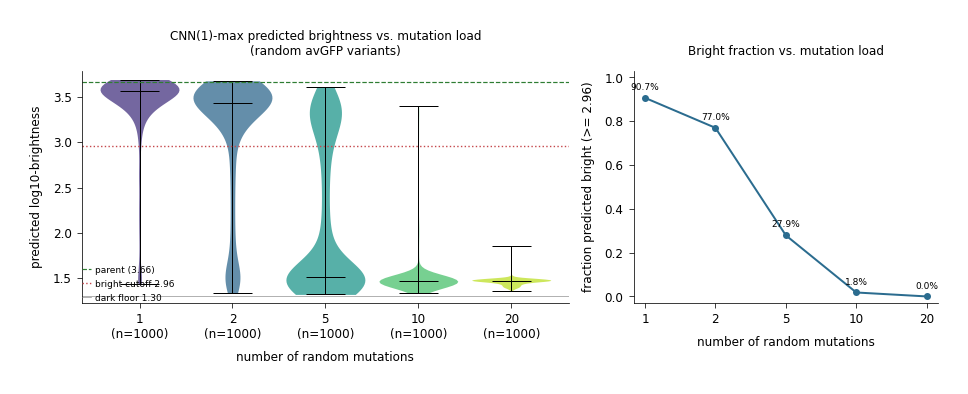

In [10]:
# Distribution of predicted brightness per mutation load + the bright-fraction trend.
DARK_FLOOR = np.log10(20)            # DMS dark-variant floor ~1.30
BRIGHT_CUT = 2.96                    # brightness cutoff used to screen designs
levels = MUT_LEVELS
data   = [mut_results[k] for k in levels]
cmap   = plt.cm.viridis(np.linspace(0.15, 0.9, len(levels)))

fig, (axV, axF) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1]})

# --- left: violin (distribution) per mutation level ---
parts = axV.violinplot(data, positions=range(len(levels)), showmedians=True, widths=0.85)
for i, b in enumerate(parts["bodies"]):
    b.set_facecolor(cmap[i]); b.set_edgecolor("k"); b.set_alpha(0.75)
for key in ("cmedians", "cbars", "cmins", "cmaxes"):
    if key in parts:
        parts[key].set_color("k"); parts[key].set_linewidth(1.0)
axV.axhline(wt_pred, ls="--", lw=1.2, color="#2e7d32", label=f"parent ({wt_pred:.2f})")
axV.axhline(BRIGHT_CUT, ls=":",  lw=1.4, color="#c5474b", label=f"bright cutoff {BRIGHT_CUT}")
axV.axhline(DARK_FLOOR, ls="-",  lw=1.0, color="gray", alpha=0.6, label=f"dark floor {DARK_FLOOR:.2f}")
axV.set_xticks(range(len(levels)))
axV.set_xticklabels([f"{k}\n(n={N_PER_LEVEL})" for k in levels])
axV.set_xlabel("number of random mutations")
axV.set_ylabel(f"predicted {UNIT}")
axV.set_title("CNN(1)-max predicted brightness vs. mutation load\n(random avGFP variants)")
axV.legend(fontsize=9, loc="lower left")

# --- right: fraction predicted bright (>= cutoff) vs mutation load ---
frac = [(mut_results[k] >= BRIGHT_CUT).mean() for k in levels]
axF.plot(range(len(levels)), frac, "o-", color="#2b6c8f", lw=2, ms=7)
for x, y in zip(range(len(levels)), frac):
    axF.annotate(f"{y:.1%}", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9)
axF.set_xticks(range(len(levels))); axF.set_xticklabels(levels)
axF.set_ylim(-0.03, 1.03)
axF.set_xlabel("number of random mutations")
axF.set_ylabel(f"fraction predicted bright (>= {BRIGHT_CUT})")
axF.set_title("Bright fraction vs. mutation load")
plt.tight_layout(); plt.show()